My project is about classifying flowers using a quantum machine learning model. I used the Iris dataset and implemented a Variational Quantum Classifier using Qiskit.

What is the Iris dataset?


The Iris dataset contains measurements of flowers such as sepal length, sepal width, petal length, and petal width. The goal is to classify the flower into three categories: Setosa, Versicolor, and Virginica.

In this step, we install the required libraries for the project.
Qiskit is used for building quantum circuits and quantum machine learning models.
qiskit-machine-learning provides algorithms such as Variational Quantum Classifier (VQC).
These libraries allow us to combine quantum computing with machine learning.

In [1]:
pip install qiskit

In this step, we create a simple quantum circuit using Qiskit.
A Hadamard gate is applied to a qubit to create superposition.
This demonstrates how quantum states can represent multiple values at once.
This concept is important for quantum machine learning.

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.h(0)

print(qc)

   ┌───┐
q: ┤ H ├
   └───┘


In [3]:
!pip install qiskit-aer



In this step, a simple quantum circuit is created using Qiskit.
A Hadamard gate is applied to the qubit to create superposition.
The qubit is then measured and the circuit is executed on the AerSimulator
for 1000 shots. The output shows how many times the result is 0 and 1.

In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1,1)

qc.h(0)

qc.measure(0,0)

simulator = AerSimulator()

result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()

print(counts)

{'0': 496, '1': 504}


In this step, we load the Iris dataset from sklearn.
The Iris dataset contains measurements of flowers such as sepal length,
sepal width, petal length, and petal width.

The goal of the model is to classify the flower into one of three categories:
Setosa, Versicolor, or Virginica.

The dataset is divided into training data and testing data.
The training data is used to train the quantum model,
while the testing data is used to evaluate the model performance.

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# dataset load
X, y = load_iris(return_X_y=True)

# training and testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train[:5])
print(y_train[:5])

[[4.9 2.5 4.5 1.7]
 [5.6 2.5 3.9 1.1]
 [6.4 3.2 4.5 1.5]
 [5.  3.5 1.6 0.6]
 [5.7 2.6 3.5 1. ]]
[2 1 1 0 1]


A feature map is used to encode classical data into quantum states.
The ZZFeatureMap converts the flower measurements into quantum information
that can be processed by a quantum circuit.

In [6]:
from qiskit.circuit.library import ZZFeatureMap

# feature map create
feature_map = ZZFeatureMap(feature_dimension=4, reps=2)

# circuit display
print(feature_map)

     ┌────────────────────────────────────┐
q_0: ┤0                                   ├
     │                                    │
q_1: ┤1                                   ├
     │  ZZFeatureMap(x[0],x[1],x[2],x[3]) │
q_2: ┤2                                   ├
     │                                    │
q_3: ┤3                                   ├
     └────────────────────────────────────┘


/tmp/ipykernel_15751/3391807129.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4, reps=2)


In [7]:
!pip install qiskit-machine-learning

In [8]:
!pip install qiskit-algorithms

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

The Variational Quantum Classifier (VQC) combines the feature map and ansatz
to create a quantum machine learning model.
The optimizer updates the parameters to minimize classification error.

The ansatz is a parameterized quantum circuit used for learning patterns in the data.

TwoLocal is used as the ansatz circuit, which contains trainable parameters.
During training, the optimizer adjusts these parameters to improve classification accuracy.

In [43]:
from qiskit.circuit.library import ZZFeatureMap, TwoLocal
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA

# quantum circuits
feature_map = ZZFeatureMap(feature_dimension=4,reps=2)
ansatz = TwoLocal(4, ['ry','rz'], 'cz',reps=2)

# faster optimizer
optimizer = COBYLA(maxiter=150)

# model
vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer)
# train
vqc.fit(X_train, y_train)

# test
accuracy = vqc.score(X_test, y_test)

print("Model Accuracy:", accuracy)

/tmp/ipykernel_15751/239599585.py:6: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4,reps=2)
/tmp/ipykernel_15751/239599585.py:7: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(4, ['ry','rz'], 'cz',reps=2)


Model Accuracy: 0.6666666666666666


In this step, the quantum classifier is trained using the training dataset.
The model learns patterns between the flower measurements and their categories.

After training, the model is tested using the testing dataset.
Accuracy measures how many predictions are correct.

Model Accuracy are : 0.6666, so - 66%

In [44]:
from sklearn.metrics import accuracy_score

y_pred = vqc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.6666666666666666


In this step, a scatter plot is created to visualize the distribution of the Iris dataset.
Sepal length is shown on the x-axis and petal length on the y-axis.
Different colors represent different flower classes, helping to understand how the data is distributed.

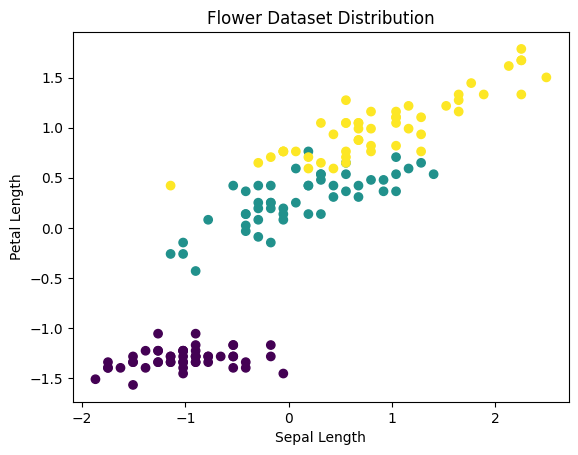

In [58]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,2], c=y)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.title("Flower Dataset Distribution")

plt.show()

The confusion matrix shows how many predictions are correct
and how many are incorrect for each flower category.
It helps evaluate the performance of the classifier.

In [59]:
from sklearn.metrics import confusion_matrix

y_pred = vqc.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13  1  0]
 [ 4  7  0]
 [ 4  1  0]]


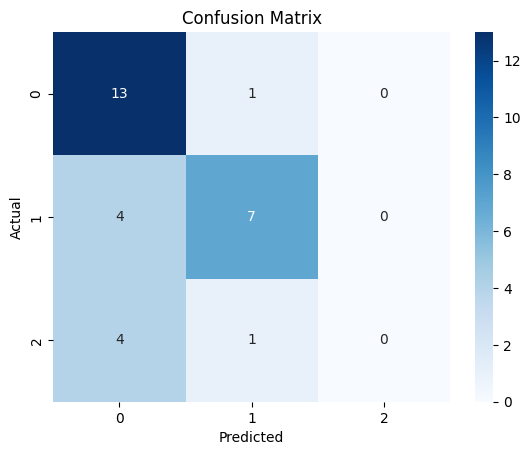

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
!pip install pylatexenc

In [15]:
!pip install pylatexenc matplotlib

In [16]:
!pip install matplotlib-venn

In this step, the feature map and ansatz quantum circuits are visualized.
The draw("mpl") function displays the structure of the circuits using matplotlib.
This helps to understand how data is encoded and how the quantum model is built.

In [48]:
import matplotlib.pyplot as plt
feature_map.draw("mpl")
plt.show()

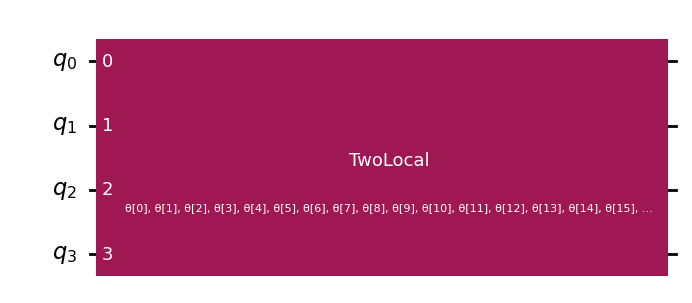

In [49]:
feature_map.draw("mpl")
ansatz.draw("mpl")

The model predicts that the given measurements belong to a Setosa flower.

In [57]:
sample = [[5.1, 3.5, 1.4, 0.2]] # Versicolor [[6.0, 2.9, 4.5, 1.5]], Virginica [[6.0, 2.9, 4.5, 1.5]]

prediction = vqc.predict(sample)

flowers = ["Setosa","Versicolor","Virginica"]

print("Flower:", flowers[int(prediction)])

Flower: Setosa


Conclusion:

 This project uses the Iris dataset and a Variational Quantum Classifier implemented in Qiskit. The feature map encodes classical data into quantum states, and the ansatz learns patterns in the data. The model is trained and then used to classify flowers into Setosa, Versicolor, or Virginica.

 The Iris dataset is a standard dataset used for classification problems in machine learning, so it is suitable for demonstrating the Variational Quantum Classifier model.